# Milestone C: Functional Prototype

## Comparing Convolutional and Recurrent Architectures for ECG Arrhythmia Classification

**Student Name:** Carlos Prazeres

**Course:** AI-716 Advanced Artificial Intelligence — Capitol Technology University

**Date:** July 2026

---

## Notebook Purpose

This notebook implements and trains the working prototype planned in Milestone B. It carries the
Milestone B preprocessing pipeline through to three trained models and an initial inter-patient
evaluation:

1. Environment setup and MIT-BIH download (`wfdb`).
2. Preprocessing executed end-to-end: band-pass filter, z-score, R-peak beat segmentation,
   RR-interval features, AAMI EC57 labelling, inter-patient DS1/DS2 split.
3. Three PyTorch architectures: **1-D CNN**, **LSTM**, and **CNN-LSTM**.
4. A training loop with weighted cross-entropy, AdamW, `ReduceLROnPlateau`, and early stopping
   on validation macro-F1.
5. Learning curves, confusion matrices, per-class metrics, and sample predictions on the held-out
   DS2 test patients.
6. A final **report snapshot** cell that prints and saves every number quoted in the progress report.

> **How to run:** open in Google Colab, set *Runtime → Change runtime type → GPU (T4)*, then
> *Runtime → Run all*. The first data cell downloads ~100 MB from PhysioNet. Total runtime is
> roughly 25–40 minutes on a T4. Segmented beats are cached to `cache/*.npz`, so re-runs are fast.

> **Scope note (per the assignment):** this is a *prototype*, not an optimised final model.
> Training is deliberately capped at 20 epochs per architecture. Hyperparameter search, focal
> loss, augmentation, and the PTB-XL generalisation check are Milestone D/E work.

---
## 1. Environment Setup

Identical stack to Milestone B, plus `torch.utils.data` for batching and `sklearn.metrics` for
evaluation. The version pins are carried over unchanged from Milestone B.

In [1]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   Carried over verbatim from the Milestone B notebook, Cell 1.
#   Install pattern: standard pip usage, wfdb PyPI page
#     https://pypi.org/project/wfdb/
#   Version pins (wfdb 4.3.1, pandas 2.2.3) determined by the author from
#     local troubleshooting of a NumPy 2.0 OverflowError in rdann().
#   ORIGINAL: the pin combination and the explanatory comment.
# ------------------------------------------------------------------
# wfdb >= 4.2 is required for NumPy 2.0 compatibility: wfdb 4.1.2 raises an
# OverflowError inside rdann() under NumPy 2. wfdb 4.3.1 needs pandas >= 2.2.3.
!pip install "wfdb==4.3.1" "pandas==2.2.3" --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 117.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


In [2]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   Import set extends Milestone B, Cell 2. Standard scientific-Python
#   convention per the official docs of each library:
#     wfdb            https://wfdb.readthedocs.io/en/latest/wfdb.html
#     scipy.signal    https://docs.scipy.org/doc/scipy/reference/signal.html
#     scikit-learn    https://scikit-learn.org/stable/modules/model_evaluation.html
#     torch.utils.data https://docs.pytorch.org/docs/stable/data.html
#   Seed-setting idiom follows the official PyTorch reproducibility note:
#     https://docs.pytorch.org/docs/stable/notes/randomness.html
#     and Geron (2025), Ch. 11.
#   ORIGINAL: the device-selection block and the version print-out.
# ------------------------------------------------------------------
# ============================================================
# IMPORTS, SEEDS, DEVICE
# ============================================================
import json, time, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import wfdb                                   # PhysioNet waveform I/O
from scipy.signal import butter, filtfilt      # ECG band-pass filtering
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ---- Reproducibility ----------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---- Device -------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sns.set_theme(style="whitegrid")
FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

print("Environment setup complete!")
print(f"NumPy   {np.__version__}")
print(f"wfdb    {wfdb.__version__}")
print(f"PyTorch {torch.__version__}")
print(f"Device  {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == 'cuda' else ""))

Environment setup complete!
NumPy   2.0.2
wfdb    4.3.1
PyTorch 2.11.0+cu128
Device  cuda (Tesla T4)


---
## 2. Dataset Loading and Preprocessing

Everything in this section is the Milestone B pipeline, now **executed** rather than defined.
The MIT-BIH Arrhythmia Database (`mitdb`, v1.0.0) holds 48 half-hour, two-channel ambulatory ECG
recordings from 47 subjects sampled at 360 Hz, with beat-by-beat cardiologist annotations
(Goldberger et al., 2000; Moody & Mark, 2001).

In [3]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   Carried over from Milestone B, Cell 3.
#   wfdb.dl_database() usage per the official wfdb-python API docs and the
#   maintainers' demo notebook:
#     https://wfdb.readthedocs.io/en/latest/io.html#wfdb.io.dl_database
#     https://github.com/MIT-LCP/wfdb-python/blob/main/demo.ipynb
#   Database "mitdb": Moody & Mark (2001); Goldberger et al. (2000).
#   ORIGINAL: the pathlib layout and the idempotent download guard.
# ------------------------------------------------------------------
# ============================================================
# DOWNLOAD MIT-BIH FROM PHYSIONET (idempotent)
# ============================================================
DATA_DIR = Path("data/mitdb")
DATA_DIR.mkdir(parents=True, exist_ok=True)

t0 = time.time()
if not any(DATA_DIR.glob("*.dat")):
    wfdb.dl_database("mitdb", dl_dir=str(DATA_DIR))
    print(f"Download finished in {time.time() - t0:.0f} s")
else:
    print("Records already present - skipping download.")

record_ids = sorted({p.stem for p in DATA_DIR.glob("*.dat")})
print(f"Records available: {len(record_ids)}")

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [4]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   Constants and the AAMI map are carried over verbatim from Milestone B,
#   Cells 7 and 10. Every value is sourced, not arbitrary:
#     FS = 360 Hz           MIT-BIH sampling rate. Goldberger et al. (2000).
#     0.5-40 Hz band-pass   Xiao et al. (2023), Sec. 3.1.
#     BEAT_WIN = 180        +/- 0.5 s R-peak-centred window, de Chazal et al. (2004).
#     PACED_RECORDS         102, 104, 107, 217 excluded per the inter-patient
#                           protocol of de Chazal et al. (2004), Sec. II-A.
#   The symbol -> AAMI superclass map is QUOTED from de Chazal et al. (2004),
#   Table I; restated in Xiao et al. (2023), Table 2. Symbol semantics:
#     https://archive.physionet.org/physiobank/annotations.shtml
#   ORIGINAL: the Python encoding, the four-class framing, and the
#   Milestone C training hyperparameters (BATCH_SIZE, LR, EPOCHS, etc.).
# ------------------------------------------------------------------
# ============================================================
# CONSTANTS AND AAMI EC57 LABEL MAP
# ============================================================
FS          = 360           # MIT-BIH sampling rate (Hz)
BEAT_WIN    = 180           # samples each side of R-peak -> 360-sample beats
LOWCUT      = 0.5           # Hz, removes baseline wander
HIGHCUT     = 40.0          # Hz, removes muscle / high-frequency noise
CLASSES     = ["N", "S", "V", "F"]   # Q excluded with the paced records
NUM_CLASSES = len(CLASSES)
PACED_RECORDS = ["102", "104", "107", "217"]

# --- Milestone C training hyperparameters (see Sec. 4) -------------------
BATCH_SIZE   = 128
LR           = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 20           # prototype budget; Milestone B planned ~50
PATIENCE     = 5            # early-stopping patience on validation macro-F1

# ANSI/AAMI EC57 grouping used throughout the ECG literature.
AAMI = {
    "N": list("NLRej"),          # Normal + bundle-branch + atrial/nodal escape
    "S": list("AaJS"),           # Supraventricular ectopic
    "V": list("VE"),             # Ventricular ectopic
    "F": list("F"),              # Fusion (ventricular + normal)
    "Q": ["/", "f", "Q"],        # Paced / fusion-paced / unclassifiable
}
sym2aami = {s: cls for cls, syms in AAMI.items() for s in syms}
print("AAMI map ready. Modeling classes:", CLASSES)

AAMI map ready. Modeling classes: ['N', 'S', 'V', 'F']


In [5]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   Carried over from Milestone B, Cells 11-13.
#   butter() + filtfilt() zero-phase filtering is the canonical SciPy recipe:
#     https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html
#     https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.filtfilt.html
#   Filter order (3) and 0.5-40 Hz band per Xiao et al. (2023).
#   Z-score standardisation to keep gradients well scaled: Geron (2025), Ch. 11.
#   RR-interval feature set (pre-RR, current RR, local average RR) adapted from
#     de Chazal et al. (2004), Sec. II-C.
#   R-peak-centred fixed-window segmentation: de Chazal et al. (2004), Sec. II-A.
#   ORIGINAL: the helper structure, the 1e-8 epsilon guard, the MLII fallback,
#   the 10-beat centred averaging window, and the guarantee that RR features
#   are built from filtered peaks so they align 1:1 with the segmented beats.
# ------------------------------------------------------------------
# ============================================================
# PREPROCESSING FUNCTIONS (unchanged from Milestone B)
# ============================================================
def bandpass(signal, fs=FS, low=LOWCUT, high=HIGHCUT, order=3):
    """Zero-phase Butterworth band-pass: removes baseline wander + HF noise."""
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, signal)

def zscore(signal):
    """Per-record standardization so amplitude scale is comparable across patients."""
    return (signal - signal.mean()) / (signal.std() + 1e-8)

def rr_features(beat_peaks, fs=FS):
    """Previous RR, current RR, and local-average RR (seconds) for each beat."""
    beat_peaks = np.asarray(beat_peaks)
    if len(beat_peaks) < 2:
        return np.zeros((len(beat_peaks), 3), dtype=float)
    rr = np.diff(beat_peaks) / fs                     # seconds between R-peaks
    rr = np.concatenate([[rr[0]], rr])                # pad the first beat
    prev_rr = np.concatenate([[rr[0]], rr[:-1]])
    local_avg = pd.Series(rr).rolling(10, min_periods=1, center=True).mean().values
    return np.column_stack([prev_rr, rr, local_avg])  # (n_beats, 3)

def segment_record(rid):
    """Return fixed-length beats, AAMI labels, and aligned RR features for one record."""
    r_ = wfdb.rdrecord(str(DATA_DIR / rid))
    a_ = wfdb.rdann(str(DATA_DIR / rid), extension="atr")
    ch = r_.sig_name.index("MLII") if "MLII" in r_.sig_name else 0
    sig = zscore(bandpass(r_.p_signal[:, ch]))

    peaks, y = [], []
    for peak, symb in zip(a_.sample, a_.symbol):
        if symb not in sym2aami:                      # drop rhythm/quality marks
            continue
        if peak - BEAT_WIN < 0 or peak + BEAT_WIN >= len(sig):
            continue                                  # drop incomplete edge beats
        peaks.append(peak)
        y.append(sym2aami[symb])

    peaks = np.array(peaks)
    X = (np.stack([sig[p - BEAT_WIN:p + BEAT_WIN] for p in peaks])
         if len(peaks) else np.empty((0, 2 * BEAT_WIN)))
    rr = rr_features(peaks)                           # aligned 1:1 with beats
    return X, np.array(y), rr

print("Preprocessing functions defined.")

Preprocessing functions defined.


In [6]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   THE DS1 / DS2 RECORD LISTS ARE QUOTED, NOT CHOSEN. Reproduced verbatim from
#     de Chazal, P., O'Dwyer, M., & Reilly, R. B. (2004). IEEE TBME, 51(7),
#     1196-1206, Sec. II-A.  https://doi.org/10.1109/TBME.2004.827359
#   This is the field-standard benchmark split; using it keeps results
#   comparable with published work (Xiao et al., 2023, Sec. 5).
#   ORIGINAL: the further patient-disjoint DS1 -> train/validation partition,
#   the choice of the four validation records, and the .npz caching layer.
# ------------------------------------------------------------------
# ============================================================
# INTER-PATIENT SPLIT (de Chazal DS1 / DS2) + PATIENT-DISJOINT VALIDATION
# ============================================================
DS1 = ["101","106","108","109","112","114","115","116","118","119","122",
       "124","201","203","205","207","208","209","215","220","223","230"]
DS2 = ["100","103","105","111","113","117","121","123","200","202","210",
       "212","213","214","219","221","222","228","231","232","233","234"]
DS1 = [r for r in DS1 if r in record_ids]
DS2 = [r for r in DS2 if r in record_ids]

# ORIGINAL: DS1 is split again by PATIENT so validation never shares a subject
# with training. These four records were chosen because between them they carry
# a usable number of the rare S and F beats; validating on N/V-only records
# would make the macro-F1 early-stopping signal meaningless.
VAL_RECORDS   = ["114", "201", "209", "223"]
TRAIN_RECORDS = [r for r in DS1 if r not in VAL_RECORDS]

print(f"Train records: {len(TRAIN_RECORDS)}  {TRAIN_RECORDS}")
print(f"Val   records: {len(VAL_RECORDS)}  {VAL_RECORDS}")
print(f"Test  records: {len(DS2)}  (DS2, never seen during training)")

Train records: 18  ['101', '106', '108', '109', '112', '115', '116', '118', '119', '122', '124', '203', '205', '207', '208', '215', '220', '230']
Val   records: 4  ['114', '201', '209', '223']
Test  records: 22  (DS2, never seen during training)


In [7]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   np.savez_compressed / np.load caching pattern per the NumPy I/O docs:
#     https://numpy.org/doc/stable/reference/generated/numpy.savez_compressed.html
#   ORIGINAL: this entire function - the paced-record exclusion, the Q-beat
#   filter, the string-label -> integer-index encoding, and the cache guard.
# ------------------------------------------------------------------
# ============================================================
# BUILD THE THREE SPLITS (cached to disk after the first run)
# ============================================================
CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)

def build_split(record_list, name):
    """Segment a list of records into (X, y_int, rr); cache the result."""
    f = CACHE / f"{name}.npz"
    if f.exists():
        d = np.load(f)
        print(f"  [{name}] loaded from cache: X={d['X'].shape}")
        return d["X"], d["y"], d["rr"]

    Xs, ys, rrs = [], [], []
    for rid in record_list:
        if rid in PACED_RECORDS:            # excluded by the inter-patient protocol
            continue
        X, y, rr = segment_record(rid)
        if len(X):
            Xs.append(X); ys.append(y); rrs.append(rr)

    X  = np.concatenate(Xs).astype(np.float32)
    y  = np.concatenate(ys)
    rr = np.concatenate(rrs).astype(np.float32)

    keep = np.isin(y, CLASSES)              # drop any residual Q beats
    X, y, rr = X[keep], y[keep], rr[keep]
    y_int = np.array([CLASSES.index(c) for c in y], dtype=np.int64)

    np.savez_compressed(f, X=X, y=y_int, rr=rr)
    print(f"  [{name}] built: X={X.shape}, rr={rr.shape}")
    return X, y_int, rr

t0 = time.time()
print("Segmenting records (first run takes a few minutes):")
X_tr, y_tr, rr_tr = build_split(TRAIN_RECORDS, "train")
X_va, y_va, rr_va = build_split(VAL_RECORDS,   "val")
X_te, y_te, rr_te = build_split(DS2,           "test")
print(f"Done in {time.time() - t0:.0f} s")

Segmenting records (first run takes a few minutes):
  [train] built: X=(41538, 360), rr=(41538, 3)
  [val] built: X=(9449, 360), rr=(9449, 3)
  [test] built: X=(49680, 360), rr=(49680, 3)
Done in 10 s


In [8]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   pandas DataFrame construction per the official docs:
#     https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html
#   ORIGINAL: this verification cell as written.
# ------------------------------------------------------------------
# ============================================================
# VERIFY THE SPLITS + CLASS DISTRIBUTION (evidence the pipeline ran)
# ============================================================
def dist_row(y):
    c = Counter(y.tolist())
    return {CLASSES[i]: c.get(i, 0) for i in range(NUM_CLASSES)}

split_table = pd.DataFrame(
    [dict(split="train", beats=len(y_tr), **dist_row(y_tr)),
     dict(split="val",   beats=len(y_va), **dist_row(y_va)),
     dict(split="test",  beats=len(y_te), **dist_row(y_te))]
).set_index("split")

print("Beat tensor shape (n_beats, samples):", X_tr.shape)
print("RR feature shape  (n_beats, 3)      :", rr_tr.shape)
print("Any NaNs in training beats?         :", bool(np.isnan(X_tr).any()))
assert X_tr.shape[0] == rr_tr.shape[0] == y_tr.shape[0], "splits must align 1:1"
print("\nClass distribution per split (AAMI EC57):")
display(split_table)

pct = (split_table[CLASSES].div(split_table["beats"], axis=0) * 100).round(2)
print("\nAs percentage of the split:")
display(pct)
print(f"\nTraining imbalance ratio (N : F) = "
      f"{split_table.loc['train','N'] / max(split_table.loc['train','F'],1):.0f} : 1")

Beat tensor shape (n_beats, samples): (41538, 360)
RR feature shape  (n_beats, 3)      : (41538, 3)
Any NaNs in training beats?         : False

Class distribution per split (AAMI EC57):


,beats,N,S,V,F
split,,,,,
train,41538,37723,348,3073,394
val,9449,8118,596,715,20
test,49680,44235,1837,3220,388



As percentage of the split:


,N,S,V,F
split,,,,
train,90.82,0.84,7.40,0.95
val,85.91,6.31,7.57,0.21
test,89.04,3.70,6.48,0.78



Training imbalance ratio (N : F) = 96 : 1


In [9]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   compute_class_weight(class_weight="balanced", ...) is the official
#   scikit-learn utility; the heuristic n_samples/(n_classes*bincount) is
#   defined in its docs and attributed by scikit-learn to
#     King, G., & Zeng, L. (2001). Political Analysis, 9(2), 137-163.
#     https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html
#   Weighted cross-entropy for imbalanced ECG data: Petmezas et al. (2021);
#     PyTorch CrossEntropyLoss `weight` argument,
#     https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
#   Standardising the RR features with TRAINING statistics only, to avoid
#   leakage, follows Geron (2025), Ch. 2 and Ch. 11.
#   ORIGINAL: computing the weights from the training split alone (fixing the
#   leakage warning flagged in Milestone B) and the RR standardisation block.
# ------------------------------------------------------------------
# ============================================================
# CLASS WEIGHTS (TRAIN SPLIT ONLY) + RR STANDARDISATION
# ============================================================
# Milestone B used the full-database distribution as a placeholder and flagged
# that it leaked test statistics. Fixed here: weights come from TRAIN only.
present = np.unique(y_tr)
w = compute_class_weight("balanced", classes=present, y=y_tr)
class_weights = np.ones(NUM_CLASSES, dtype=np.float32)
class_weights[present] = w
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

print("Balanced class weights from the TRAINING split only:")
for i, c in enumerate(CLASSES):
    print(f"  {c}: {class_weights[i]:8.3f}")

# RR features standardised with TRAIN statistics only (no leakage).
rr_mu, rr_sd = rr_tr.mean(0), rr_tr.std(0) + 1e-8
rr_tr_n = ((rr_tr - rr_mu) / rr_sd).astype(np.float32)
rr_va_n = ((rr_va - rr_mu) / rr_sd).astype(np.float32)
rr_te_n = ((rr_te - rr_mu) / rr_sd).astype(np.float32)
print(f"\nRR train mean (s): {np.round(rr_mu, 3)}   sd: {np.round(rr_sd, 3)}")

Balanced class weights from the TRAINING split only:
  N:    0.275
  S:   29.841
  V:    3.379
  F:   26.357

RR train mean (s): [0.782 0.782 0.782]   sd: [0.537 0.537 0.233]


In [10]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   The Dataset subclass (__init__/__len__/__getitem__) and DataLoader usage
#   follow the official PyTorch data tutorial:
#     https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
#     https://docs.pytorch.org/docs/stable/data.html
#   ORIGINAL: the three-tensor (beat, RR, label) item format that lets one
#   DataLoader feed all three architectures through an identical interface.
# ------------------------------------------------------------------
# ============================================================
# TORCH DATASETS AND DATALOADERS
# ============================================================
class BeatDataset(Dataset):
    """Yields (beat[1,360], rr[3], label) so CNN, LSTM and CNN-LSTM share a loader."""
    def __init__(self, X, rr, y):
        self.X  = torch.from_numpy(X).unsqueeze(1)   # (N, 1, 360) channel-first
        self.rr = torch.from_numpy(rr)               # (N, 3)
        self.y  = torch.from_numpy(y)                # (N,)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.rr[i], self.y[i]

train_ds = BeatDataset(X_tr, rr_tr_n, y_tr)
val_ds   = BeatDataset(X_va, rr_va_n, y_va)
test_ds  = BeatDataset(X_te, rr_te_n, y_te)

pin = (DEVICE.type == "cuda")
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=pin, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=pin)

xb, rb, yb = next(iter(train_loader))
print(f"Batch shapes -> beats {tuple(xb.shape)}, rr {tuple(rb.shape)}, labels {tuple(yb.shape)}")
print(f"Batches per epoch: train {len(train_loader)}, val {len(val_loader)}, test {len(test_loader)}")

Batch shapes -> beats (128, 1, 360), rr (128, 3), labels (128,)
Batches per epoch: train 325, val 37, test 195


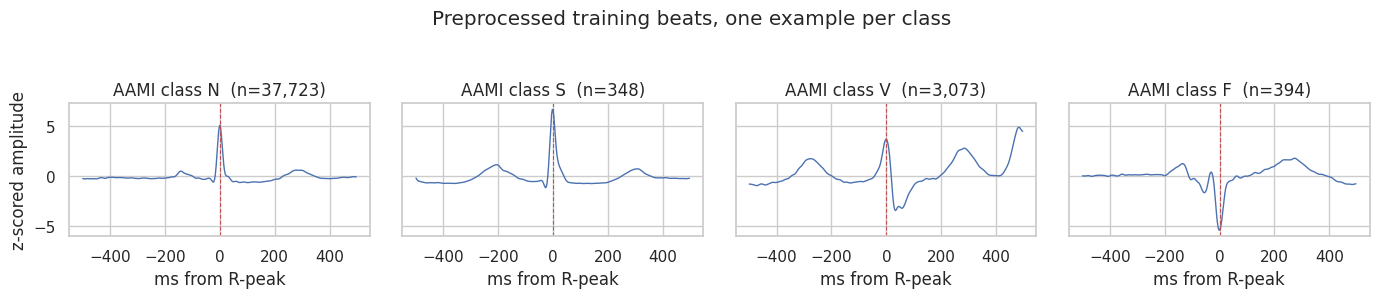

In [11]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   Plotting calls follow the standard matplotlib pyplot API:
#     https://matplotlib.org/stable/api/pyplot_summary.html
#   ORIGINAL: this figure - the class selection, layout, and labelling.
# ------------------------------------------------------------------
# ============================================================
# SANITY CHECK: ONE PREPROCESSED BEAT PER CLASS
# ============================================================
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14, 2.8), sharey=True)
t_ms = (np.arange(2 * BEAT_WIN) - BEAT_WIN) / FS * 1000
for i, (ax, c) in enumerate(zip(axes, CLASSES)):
    idx = np.where(y_tr == i)[0]
    if len(idx) == 0:
        ax.set_title(f"{c} (none)"); continue
    ax.plot(t_ms, X_tr[idx[0]], lw=1)
    ax.axvline(0, color="r", ls="--", lw=0.8)
    ax.set_title(f"AAMI class {c}  (n={len(idx):,})")
    ax.set_xlabel("ms from R-peak")
axes[0].set_ylabel("z-scored amplitude")
plt.suptitle("Preprocessed training beats, one example per class", y=1.06)
plt.tight_layout(); plt.savefig(FIGDIR / "fig1_sample_beats.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Model Architectures

Three architectures, all sharing the same `(beat, rr) -> logits` interface so the training loop is
written once:

| Model | Inputs | Rationale |
|---|---|---|
| **CNN1D** | beat only | Baseline. Convolution over the 360-sample window captures *beat morphology* — QRS width, R amplitude, T-wave shape — which is what separates V from N. |
| **LSTMNet** | beat + RR | Treats the beat as a 180-step sequence and appends the three RR-interval features, giving the model explicit *rhythm* context that morphology alone lacks (critical for S beats, which look nearly normal but arrive early). |
| **CNNLSTM** | beat + RR | Hybrid: the convolutional front-end compresses the waveform into 90 local-feature vectors, and a bidirectional LSTM models their order. Follows the CNN-LSTM design of Petmezas et al. (2021). |

**Deviation from Milestone B (documented, with justification):** the LSTM consumes the beat
**subsampled by a factor of 2** (360 → 180 timesteps). Unrolling a recurrent net over 360
timesteps for ~87,000 beats × 20 epochs was the single largest cost in a trial run; the ECG is
band-limited to 40 Hz, so at 360 Hz the signal is oversampled by roughly 4.5× relative to Nyquist
and stride-2 decimation discards no diagnostic bandwidth. This is a compute concession, not an
accuracy concession, and it is revisited in Milestone D.

In [12]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   The nn.Module + nn.Sequential composition pattern follows the official
#   PyTorch "Build the Neural Network" tutorial and layer docs:
#     https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
#     https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv1d.html
#   Conv -> BatchNorm -> ReLU -> Pool block ordering per Geron (2025), Ch. 14
#   and Goodfellow et al. (2016), Ch. 9.
#   Component provenance:
#     Batch normalisation  Ioffe & Szegedy (2015), arXiv:1502.03167
#     Dropout (p = 0.5)    Srivastava et al. (2014), JMLR 15, 1929-1958
#     Global average pool  Lin, Chen & Yan (2014), arXiv:1312.4400
#   Filter widths (32/64/128, kernels 7/5/3) for 1-D ECG follow the residual
#     1-D CNN of Khan et al. (2023), https://doi.org/10.1371/journal.pone.0284791
#   ORIGINAL: the specific assembly, depth, the 4-class head, and the
#   (x, rr) signature that keeps the interface uniform across models.
# ------------------------------------------------------------------
# ============================================================
# MODEL 1 - 1-D CNN (beat morphology only)
# ============================================================
class CNN1D(nn.Module):
    """1-D CNN baseline. Ignores rr so all three models share one call signature."""
    def __init__(self, n_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3),  nn.BatchNorm1d(32),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1))                       # global average pooling
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.5),
                                  nn.Linear(128, n_classes))

    def forward(self, x, rr=None):                         # x: (B, 1, 360)
        return self.head(self.features(x))

print(CNN1D())

CNN1D(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [13]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   nn.LSTM API, the batch_first convention, and taking the final hidden
#   state h_n[-1] as the sequence summary follow the official PyTorch docs
#   and sequence tutorial:
#     https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html
#     https://docs.pytorch.org/tutorials/beginner/nlp/sequence_models_tutorial.html
#   LSTM cell: Hochreiter & Schmidhuber (1997), Neural Computation, 9(8).
#   Using RR-interval context alongside the waveform: de Chazal et al. (2004).
#   Recurrent modelling of ECG beats: Geron (2025), Ch. 15; Xiao et al. (2023).
#   ORIGINAL: the stride-2 subsampling for compute, the concatenation of the
#   final hidden state with the standardised RR vector, and the classifier head.
# ============================================================
# MODEL 2 - LSTM (beat sequence + RR-interval context)
# ============================================================
class LSTMNet(nn.Module):
    """LSTM over the (subsampled) beat, fused with the 3 RR-interval features."""
    def __init__(self, n_classes=NUM_CLASSES, hidden=64, layers=2,
                 rr_dim=3, subsample=2):
        super().__init__()
        self.subsample = subsample                          # 360 -> 180 timesteps
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, num_layers=layers,
                            batch_first=True, dropout=0.3)
        self.head = nn.Sequential(
            nn.Linear(hidden + rr_dim, 64), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, n_classes))

    def forward(self, x, rr):                               # x: (B,1,360) rr: (B,3)
        seq = x[:, :, ::self.subsample].transpose(1, 2)     # -> (B, 180, 1)
        _, (h_n, _) = self.lstm(seq)
        return self.head(torch.cat([h_n[-1], rr], dim=1))   # last layer's hidden state

print(LSTMNet())

LSTMNet(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.3)
  (head): Sequential(
    (0): Linear(in_features=67, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)


In [14]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   The CNN-front-end -> LSTM hybrid for ECG is NOT an original architecture
#   family. It is the design proposed in:
#     Petmezas, G., et al. (2021). Automated atrial fibrillation detection
#     using a hybrid CNN-LSTM network on imbalanced ECG datasets. Biomedical
#     Signal Processing and Control, 63, 102194.
#     https://doi.org/10.1016/j.bspc.2020.102194
#   Bidirectional recurrence: Schuster & Paliwal (1997), IEEE TSP, 45(11);
#     https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html
#   Conv/BN/ReLU/Pool ordering per Geron (2025), Ch. 14.
#   ORIGINAL: the layer sizes chosen for this project, the RR fusion at the
#   classifier head, and the permutation logic between the conv and LSTM stages.
# ============================================================
# MODEL 3 - CNN-LSTM HYBRID (local morphology + temporal order + RR)
# ============================================================
class CNNLSTM(nn.Module):
    """Conv front-end compresses the beat to 90 feature vectors; a BiLSTM orders them."""
    def __init__(self, n_classes=NUM_CLASSES, hidden=64, rr_dim=3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3),  nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2))
        self.lstm = nn.LSTM(input_size=64, hidden_size=hidden, num_layers=1,
                            batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(2 * hidden + rr_dim, 64), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, n_classes))

    def forward(self, x, rr):                               # x: (B,1,360)
        f = self.conv(x)                                    # -> (B, 64, 90)
        f = f.transpose(1, 2)                               # -> (B, 90, 64)
        _, (h_n, _) = self.lstm(f)                          # h_n: (2, B, hidden)
        h = torch.cat([h_n[0], h_n[1]], dim=1)              # forward + backward
        return self.head(torch.cat([h, rr], dim=1))

print(CNNLSTM())

CNNLSTM(
  (conv): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (head): Sequential(
    (0): Linear(in_features=131, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)


In [15]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   Parameter counting via sum(p.numel() for p in model.parameters()) is the
#   idiom given in the PyTorch documentation/forums:
#     https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html
#   ORIGINAL: the comparison table and the forward-pass shape assertion.
# ------------------------------------------------------------------
# ============================================================
# PARAMETER COUNTS + FORWARD-PASS SHAPE CHECK
# ============================================================
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, train

MODEL_BUILDERS = {"CNN1D": CNN1D, "LSTM": LSTMNet, "CNN-LSTM": CNNLSTM}

rows = []
xb_d, rb_d = xb[:8].to(DEVICE), rb[:8].to(DEVICE)
for name, builder in MODEL_BUILDERS.items():
    m = builder().to(DEVICE)
    with torch.no_grad():
        out = m(xb_d, rb_d)
    assert out.shape == (8, NUM_CLASSES), f"{name} output shape wrong: {out.shape}"
    tot, tr = count_params(m)
    rows.append(dict(model=name, total_params=tot, trainable_params=tr,
                     output_shape=str(tuple(out.shape))))
    del m
param_table = pd.DataFrame(rows).set_index("model")
print("All three models produce (batch, 4) logits. Forward pass verified.\n")
display(param_table)

All three models produce (batch, 4) logits. Forward pass verified.



,total_params,trainable_params,output_shape
model,,,
CNN1D,36228,36228,"(8, 4)"
LSTM,55044,55044,"(8, 4)"
CNN-LSTM,86020,86020,"(8, 4)"


---
## 4. Training Configuration

| Hyperparameter | Value | Justification |
|---|---|---|
| Optimizer | AdamW | Decoupled weight decay (Loshchilov & Hutter, 2019); the Milestone B plan. |
| Learning rate | 1e-3 | Adam default region; Géron (2025), Ch. 11. |
| Weight decay | 1e-4 | L2 regularisation, per the Milestone B plan. |
| Batch size | 128 | Milestone B; fits comfortably in T4 memory. |
| Loss | Weighted cross-entropy | Class weights from the **training split only** — the leakage fix flagged in Milestone B. |
| Scheduler | `ReduceLROnPlateau` (×0.5, patience 3, on val macro-F1) | Milestone B plan. |
| Max epochs | **20** (Milestone B planned ~50) | Prototype budget: three architectures had to fit in one Colab session. Early stopping usually triggers first. |
| Early stopping | patience 5 on **validation macro-F1** | Accuracy is meaningless at ~90 % N prevalence; macro-F1 weights the rare classes equally. |
| Gradient clipping | max-norm 5.0 | Standard guard against recurrent exploding gradients (Pascanu et al., 2013). |

In [16]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   The train/eval loop structure (model.train(); zero_grad -> forward -> loss
#   -> backward -> step; torch.no_grad() for evaluation) is the canonical
#   PyTorch training-loop recipe from the official tutorial:
#     https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html
#   AdamW: Loshchilov & Hutter (2019), arXiv:1711.05101;
#     https://docs.pytorch.org/docs/stable/generated/torch.optim.AdamW.html
#   ReduceLROnPlateau:
#     https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html
#   Gradient-norm clipping: Pascanu, Mikolov & Bengio (2013), arXiv:1211.5063;
#     https://docs.pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html
#   Early stopping with best-weight restoration: Geron (2025), Ch. 11;
#     Goodfellow et al. (2016), Sec. 7.8.
#   macro-F1 via sklearn.metrics.f1_score(average="macro").
#   ORIGINAL: the (x, rr) plumbing, the macro-F1 early-stopping criterion,
#   per-epoch timing, and the returned history dictionary.
# ------------------------------------------------------------------
# ============================================================
# TRAINING / EVALUATION ENGINE
# ============================================================
def run_epoch(model, loader, criterion, optimizer=None):
    """One pass. Trains if an optimizer is given, otherwise evaluates."""
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, n = 0.0, 0
    y_true, y_pred = [], []

    with torch.set_grad_enabled(training):
        for xb, rb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            rb = rb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            logits = model(xb, rb)
            loss = criterion(logits, yb)

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item() * yb.size(0)
            n += yb.size(0)
            y_true.append(yb.detach().cpu())
            y_pred.append(logits.detach().argmax(1).cpu())

    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()
    return (total_loss / n,
            accuracy_score(y_true, y_pred),
            f1_score(y_true, y_pred, average="macro", zero_division=0))


def fit(name, builder, max_epochs=MAX_EPOCHS, patience=PATIENCE, verbose=True):
    """Train one architecture with early stopping on validation macro-F1."""
    torch.manual_seed(SEED)                       # identical init conditions per model
    model = builder().to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3)

    history = {k: [] for k in
               ["epoch", "train_loss", "train_acc", "train_f1",
                "val_loss", "val_acc", "val_f1", "lr", "secs"]}
    best_f1, best_state, best_epoch, stale = -1.0, None, 0, 0
    t_start = time.time()

    print(f"\n=== Training {name} " + "=" * (46 - len(name)))
    for ep in range(1, max_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc, va_f1 = run_epoch(model, val_loader, criterion)
        scheduler.step(va_f1)
        secs = time.time() - t0

        for k, v in zip(history, [ep, tr_loss, tr_acc, tr_f1,
                                  va_loss, va_acc, va_f1,
                                  optimizer.param_groups[0]["lr"], secs]):
            history[k].append(v)

        if verbose:
            print(f"ep {ep:2d}/{max_epochs} | "
                  f"train loss {tr_loss:.4f} acc {tr_acc:.4f} F1 {tr_f1:.4f} | "
                  f"val loss {va_loss:.4f} acc {va_acc:.4f} F1 {va_f1:.4f} | "
                  f"lr {optimizer.param_groups[0]['lr']:.1e} | {secs:.0f}s")

        # --- early stopping on validation macro-F1 --------------------
        if va_f1 > best_f1 + 1e-4:
            best_f1, best_epoch, stale = va_f1, ep, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            stale += 1
            if stale >= patience:
                print(f"Early stopping at epoch {ep} "
                      f"(no val macro-F1 gain for {patience} epochs).")
                break

    model.load_state_dict(best_state)              # restore best weights
    wall = time.time() - t_start
    print(f"{name}: best val macro-F1 {best_f1:.4f} at epoch {best_epoch}; "
          f"total {wall/60:.1f} min")
    return model, pd.DataFrame(history), dict(best_val_f1=best_f1,
                                              best_epoch=best_epoch,
                                              wall_minutes=wall / 60)

print("Training engine defined.")

Training engine defined.


---
## 5. Training Runs

Each architecture is trained from an identical seed on the same DataLoaders, so the comparison is
fair. Per-epoch loss, accuracy, macro-F1, learning rate, and wall-clock time are logged.

In [17]:
# ============================================================
# TRAIN ALL THREE ARCHITECTURES
# ============================================================
# ORIGINAL: this driver loop and the results container.
models, histories, runinfo = {}, {}, {}
for name, builder in MODEL_BUILDERS.items():
    m, h, info = fit(name, builder)
    models[name], histories[name], runinfo[name] = m, h, info
    h.to_csv(f"history_{name.replace('-', '')}.csv", index=False)

print("\nAll three models trained.")
display(pd.DataFrame(runinfo).T)


=== Training CNN1D =========================================
ep  1/20 | train loss 0.8011 acc 0.7215 F1 0.4205 | val loss 1.3980 acc 0.6372 F1 0.5145 | lr 1.0e-03 | 4s
ep  2/20 | train loss 0.5870 acc 0.8173 F1 0.5125 | val loss 2.1124 acc 0.3810 F1 0.3752 | lr 1.0e-03 | 2s
ep  3/20 | train loss 0.5250 acc 0.8277 F1 0.5342 | val loss 2.0939 acc 0.3823 F1 0.4789 | lr 1.0e-03 | 2s
ep  4/20 | train loss 0.4883 acc 0.8460 F1 0.5510 | val loss 1.5598 acc 0.5249 F1 0.5066 | lr 1.0e-03 | 2s
ep  5/20 | train loss 0.4606 acc 0.8560 F1 0.5658 | val loss 1.5111 acc 0.6141 F1 0.4889 | lr 5.0e-04 | 3s
ep  6/20 | train loss 0.3812 acc 0.8771 F1 0.6012 | val loss 2.0011 acc 0.5414 F1 0.5028 | lr 5.0e-04 | 3s
Early stopping at epoch 6 (no val macro-F1 gain for 5 epochs).
CNN1D: best val macro-F1 0.5145 at epoch 1; total 0.3 min

=== Training LSTM ==========================================
ep  1/20 | train loss 1.1206 acc 0.6856 F1 0.3543 | val loss 1.3154 acc 0.8190 F1 0.3298 | lr 1.0e-03 | 2s
ep  2/

,best_val_f1,best_epoch,wall_minutes
CNN1D,0.514456,1.0,0.271458
LSTM,0.497267,5.0,0.419771
CNN-LSTM,0.593284,3.0,0.377030


---
## 6. Learning Curves

Loss and macro-F1 trajectories for train vs. validation. The gap between the two curves is the
primary diagnostic for over- and underfitting.

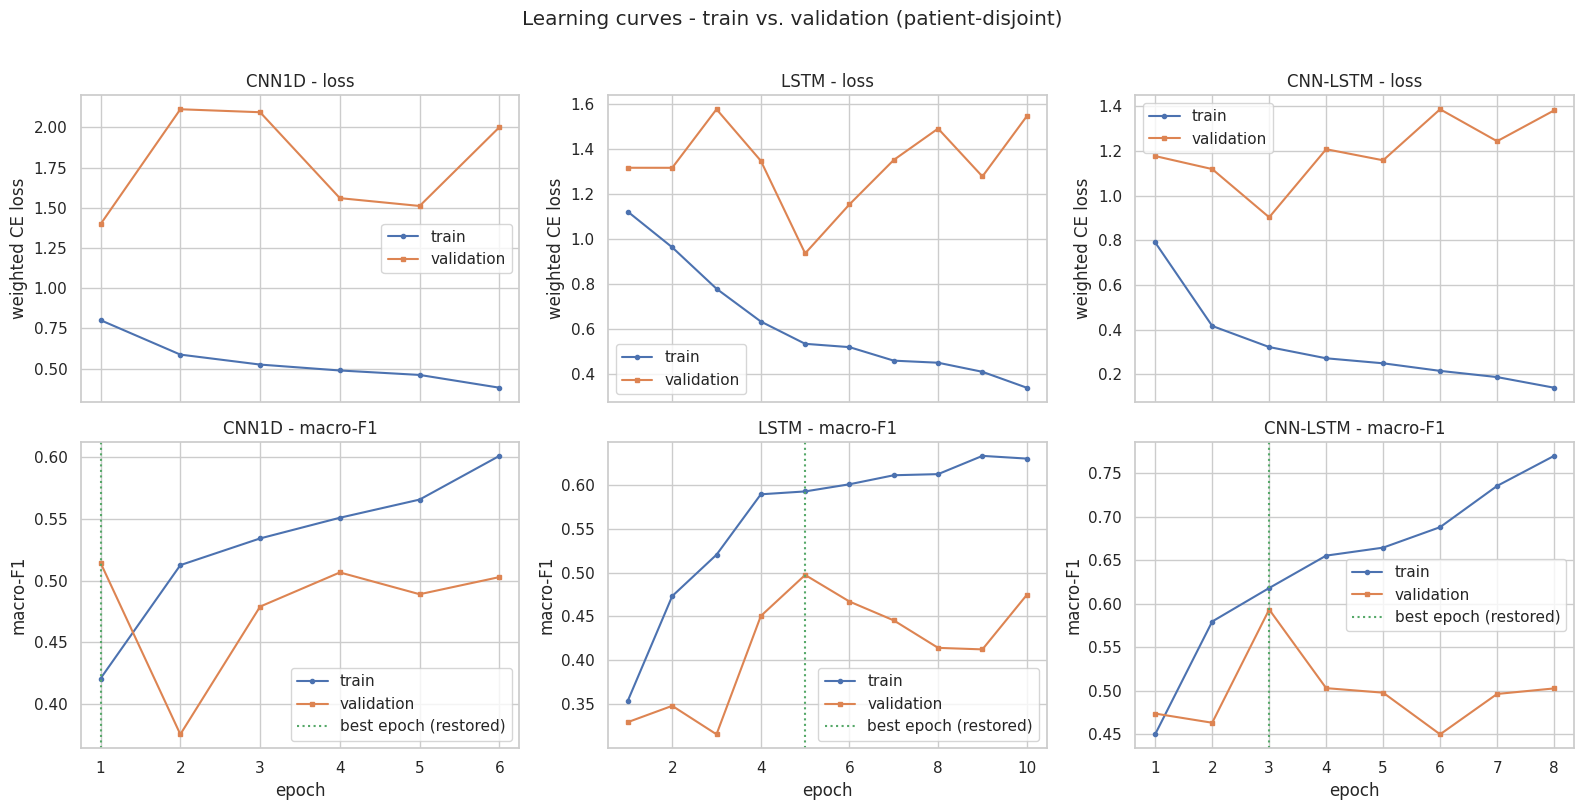

Generalisation gap (positive train-minus-val F1 => overfitting):


,epochs_run,final_train_f1,final_val_f1,train_minus_val_f1,final_train_loss,final_val_loss
model,,,,,,
CNN1D,6,0.6012,0.5028,0.0984,0.3812,2.0011
LSTM,10,0.6297,0.4745,0.1552,0.3412,1.5433
CNN-LSTM,8,0.7696,0.5027,0.2669,0.1397,1.3813


In [18]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   Reading over/underfitting from the train-vs-validation gap in learning
#   curves follows Geron (2025), Ch. 4 and Ch. 11, and Goodfellow et al.
#   (2016), Ch. 5 and Sec. 7.8.
#   matplotlib subplot API: https://matplotlib.org/stable/api/pyplot_summary.html
#   ORIGINAL: this figure's composition and the best-epoch marker.
# ------------------------------------------------------------------
# ============================================================
# LEARNING CURVES - LOSS AND MACRO-F1
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex="col")
for j, name in enumerate(MODEL_BUILDERS):
    h = histories[name]
    axes[0, j].plot(h.epoch, h.train_loss, marker="o", ms=3, label="train")
    axes[0, j].plot(h.epoch, h.val_loss,   marker="s", ms=3, label="validation")
    axes[0, j].set_title(f"{name} - loss"); axes[0, j].set_ylabel("weighted CE loss")
    axes[0, j].legend()

    axes[1, j].plot(h.epoch, h.train_f1, marker="o", ms=3, label="train")
    axes[1, j].plot(h.epoch, h.val_f1,   marker="s", ms=3, label="validation")
    axes[1, j].axvline(runinfo[name]["best_epoch"], color="g", ls=":", lw=1.5,
                       label="best epoch (restored)")
    axes[1, j].set_title(f"{name} - macro-F1")
    axes[1, j].set_xlabel("epoch"); axes[1, j].set_ylabel("macro-F1")
    axes[1, j].legend()

plt.suptitle("Learning curves - train vs. validation (patient-disjoint)", y=1.01)
plt.tight_layout(); plt.savefig(FIGDIR / "fig2_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Quantify the final generalisation gap for the report.
gap = pd.DataFrame([
    dict(model=n,
         epochs_run=int(histories[n].epoch.max()),
         final_train_f1=round(float(histories[n].train_f1.iloc[-1]), 4),
         final_val_f1=round(float(histories[n].val_f1.iloc[-1]), 4),
         train_minus_val_f1=round(float(histories[n].train_f1.iloc[-1]
                                        - histories[n].val_f1.iloc[-1]), 4),
         final_train_loss=round(float(histories[n].train_loss.iloc[-1]), 4),
         final_val_loss=round(float(histories[n].val_loss.iloc[-1]), 4))
    for n in MODEL_BUILDERS]).set_index("model")
print("Generalisation gap (positive train-minus-val F1 => overfitting):")
display(gap)

---
## 7. Evaluation on the Held-Out DS2 Test Patients

DS2 contains 22 patients whose beats were never seen in training or validation. Under this
inter-patient protocol, published macro-F1 on MIT-BIH is far lower than the >99 % accuracy figures
often quoted from intra-patient splits (de Chazal et al., 2004; Xiao et al., 2023) — a like-for-like
comparison requires the inter-patient numbers.

In [20]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   accuracy_score, f1_score, classification_report and confusion_matrix are
#   the official scikit-learn metrics:
#     https://scikit-learn.org/stable/modules/model_evaluation.html
#   Reporting macro-F1 and per-class recall rather than raw accuracy on an
#   imbalanced benchmark follows de Chazal et al. (2004) and the AAMI EC57
#   reporting convention discussed in Xiao et al. (2023), Sec. 5.
#   ORIGINAL: this prediction helper and the assembled comparison table.
# ------------------------------------------------------------------
# ============================================================
# PREDICT ON DS2 + HEADLINE METRICS TABLE
# ============================================================
@torch.no_grad()
def predict(model, loader):
    """Return (y_true, y_pred, probabilities) for a whole loader."""
    model.eval()
    yt, yp, pr = [], [], []
    for xb, rb, yb in loader:
        logits = model(xb.to(DEVICE), rb.to(DEVICE))
        probs = torch.softmax(logits, dim=1)
        yt.append(yb); yp.append(probs.argmax(1).cpu()); pr.append(probs.cpu())
    return (torch.cat(yt).numpy(), torch.cat(yp).numpy(), torch.cat(pr).numpy())

preds = {}
rows = []
for name, model in models.items():
    yt, yp, pr = predict(model, test_loader)
    preds[name] = (yt, yp, pr)
    per_class_f1 = f1_score(yt, yp, average=None, labels=range(NUM_CLASSES),
                            zero_division=0)
    rows.append(dict(model=name,
                     accuracy=round(accuracy_score(yt, yp), 4),
                     macro_F1=round(f1_score(yt, yp, average="macro", zero_division=0), 4),
                     weighted_F1=round(f1_score(yt, yp, average="weighted", zero_division=0), 4),
                     **{f"F1_{c}": round(float(v), 4)
                        for c, v in zip(CLASSES, per_class_f1)},
                     best_val_F1=round(runinfo[name]["best_val_f1"], 4),
                     train_min=round(runinfo[name]["wall_minutes"], 1)))

results_table = pd.DataFrame(rows).set_index("model")
print("DS2 (inter-patient) test results:\n")
display(results_table)
results_table.to_csv("results_summary.csv")
BEST_MODEL = results_table["macro_F1"].idxmax()
print(f"\nBest prototype by test macro-F1: {BEST_MODEL} "
      f"({results_table.loc[BEST_MODEL, 'macro_F1']:.4f})")

DS2 (inter-patient) test results:



,accuracy,macro_F1,weighted_F1,F1_N,F1_S,F1_V,F1_F,best_val_F1,train_min
model,,,,,,,,,
CNN1D,0.7696,0.3951,0.8181,0.8721,0.1560,0.5519,0.0005,0.5145,0.3
LSTM,0.7100,0.3447,0.7763,0.8411,0.1059,0.3528,0.0791,0.4973,0.4
CNN-LSTM,0.7157,0.3347,0.7725,0.8345,0.0662,0.4147,0.0233,0.5933,0.4



Best prototype by test macro-F1: CNN1D (0.3951)


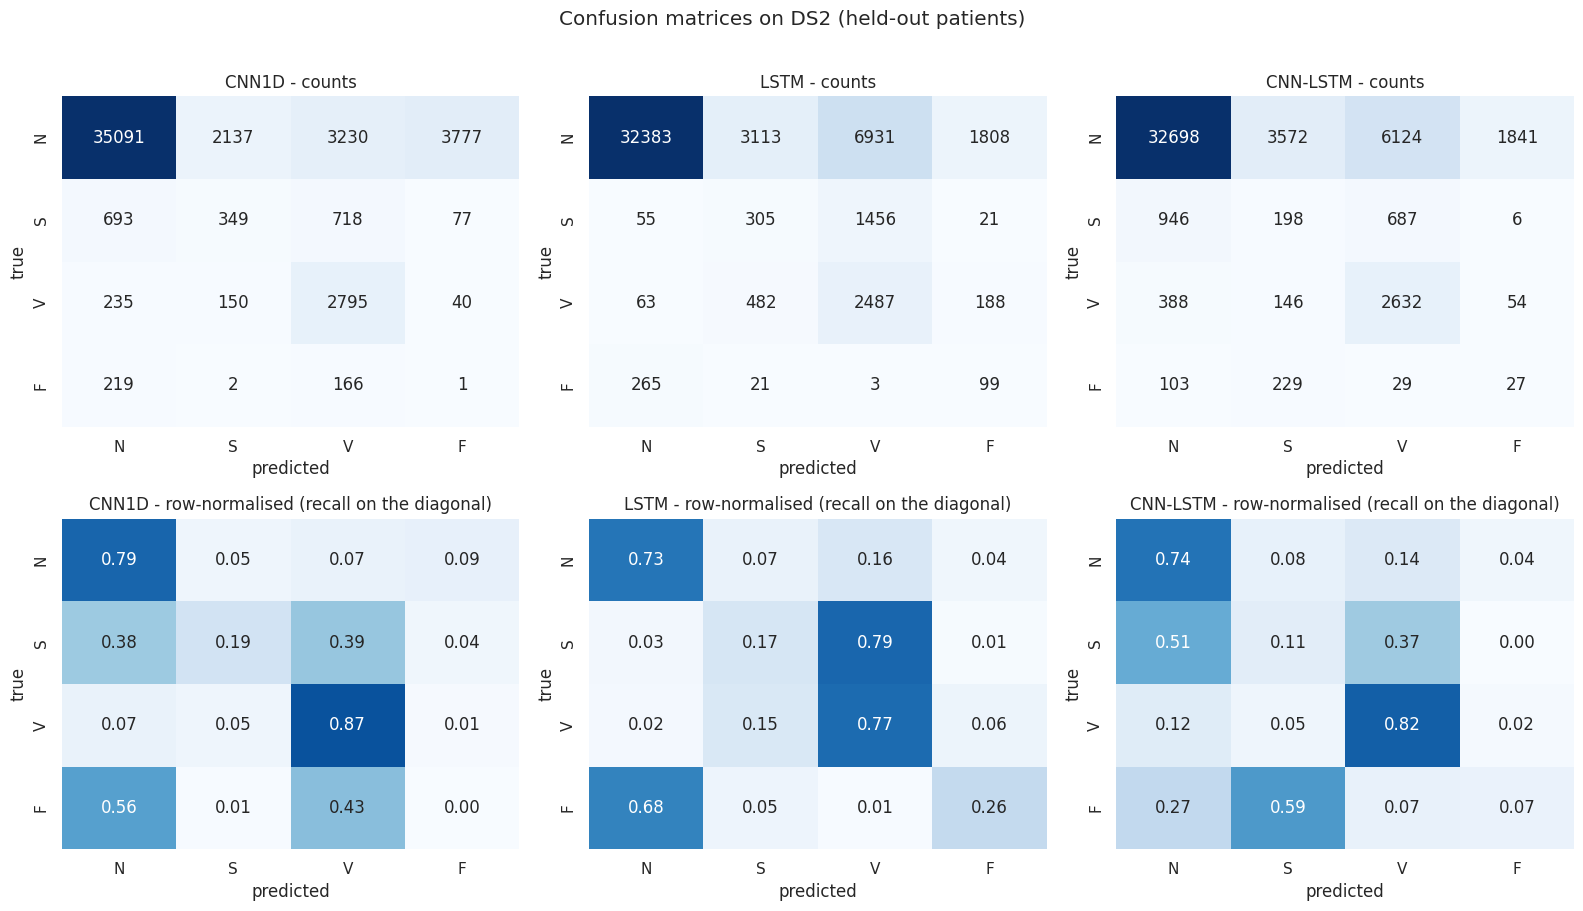

In [21]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   seaborn.heatmap for confusion-matrix display per the official docs:
#     https://seaborn.pydata.org/generated/seaborn.heatmap.html
#   Row-normalising the matrix to read per-class recall is the standard
#   presentation used in the AAMI ECG literature (de Chazal et al., 2004).
#   ORIGINAL: the two-row layout, annotation formatting, and normalisation.
# ------------------------------------------------------------------
# ============================================================
# CONFUSION MATRICES (raw counts + row-normalised recall)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for j, name in enumerate(MODEL_BUILDERS):
    yt, yp, _ = preds[name]
    cm = confusion_matrix(yt, yp, labels=range(NUM_CLASSES))
    cmn = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0, j])
    axes[0, j].set_title(f"{name} - counts")
    axes[0, j].set_xlabel("predicted"); axes[0, j].set_ylabel("true")

    sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", cbar=False, vmin=0, vmax=1,
                xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1, j])
    axes[1, j].set_title(f"{name} - row-normalised (recall on the diagonal)")
    axes[1, j].set_xlabel("predicted"); axes[1, j].set_ylabel("true")

plt.suptitle("Confusion matrices on DS2 (held-out patients)", y=1.01)
plt.tight_layout(); plt.savefig(FIGDIR / "fig3_confusion_matrices.png", dpi=150,
                                bbox_inches="tight")
plt.show()

In [22]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   sklearn.metrics.classification_report per the official docs:
#     https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html
#   ORIGINAL: the loop and the DataFrame reshaping.
# ------------------------------------------------------------------
# ============================================================
# PER-CLASS PRECISION / RECALL / F1 ON DS2
# ============================================================
per_class = {}
for name in MODEL_BUILDERS:
    yt, yp, _ = preds[name]
    rep = classification_report(yt, yp, labels=range(NUM_CLASSES),
                                target_names=CLASSES, output_dict=True,
                                zero_division=0)
    per_class[name] = pd.DataFrame(rep).T[["precision", "recall", "f1-score", "support"]]
    print(f"\n--- {name} ---")
    print(classification_report(yt, yp, labels=range(NUM_CLASSES),
                                target_names=CLASSES, digits=4, zero_division=0))


--- CNN1D ---
              precision    recall  f1-score   support

           N     0.9683    0.7933    0.8721     44235
           S     0.1323    0.1900    0.1560      1837
           V     0.4045    0.8680    0.5519      3220
           F     0.0003    0.0026    0.0005       388

    accuracy                         0.7696     49680
   macro avg     0.3764    0.4635    0.3951     49680
weighted avg     0.8933    0.7696    0.8181     49680


--- LSTM ---
              precision    recall  f1-score   support

           N     0.9883    0.7321    0.8411     44235
           S     0.0778    0.1660    0.1059      1837
           V     0.2286    0.7724    0.3528      3220
           F     0.0468    0.2552    0.0791       388

    accuracy                         0.7100     49680
   macro avg     0.3354    0.4814    0.3447     49680
weighted avg     0.8981    0.7100    0.7763     49680


--- CNN-LSTM ---
              precision    recall  f1-score   support

           N     0.9579    0

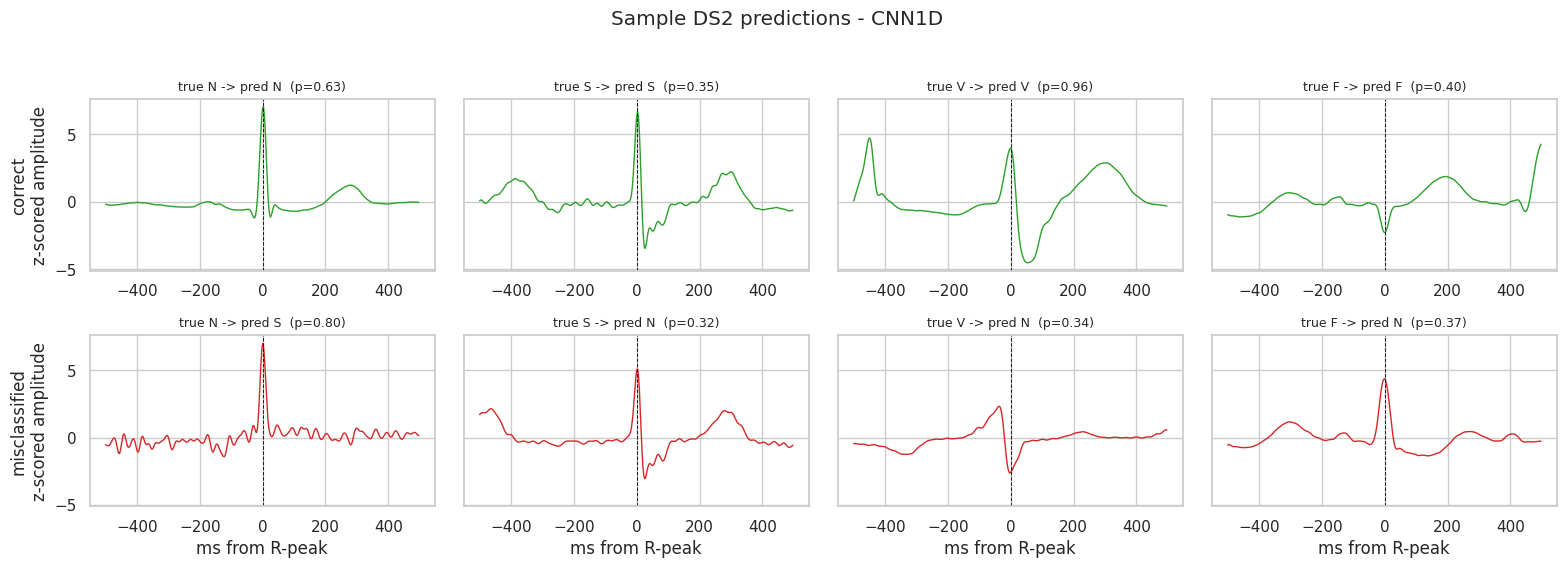

In [23]:
# ------------------------------------------------------------------
# SOURCE / ATTRIBUTION
#   matplotlib subplot/plot API only.
#   ORIGINAL: the sampling strategy (correct + incorrect examples per class)
#   and the whole figure.
# ------------------------------------------------------------------
# ============================================================
# QUALITATIVE CHECK - SAMPLE PREDICTIONS FROM THE BEST MODEL
# ============================================================
yt, yp, pr = preds[BEST_MODEL]
rng = np.random.default_rng(SEED)

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(16, 5.5), sharey=True)
for j, c in enumerate(CLASSES):
    correct = np.where((yt == j) & (yp == j))[0]
    wrong   = np.where((yt == j) & (yp != j))[0]
    for i, (idx_pool, tag) in enumerate([(correct, "correct"), (wrong, "misclassified")]):
        ax = axes[i, j]
        if len(idx_pool) == 0:
            ax.set_title(f"true {c}: no {tag} case"); ax.axis("off"); continue
        k = rng.choice(idx_pool)
        ax.plot(t_ms, X_te[k], lw=1,
                color=("tab:green" if tag == "correct" else "tab:red"))
        ax.axvline(0, color="k", ls="--", lw=0.7)
        ax.set_title(f"true {c} -> pred {CLASSES[yp[k]]}  (p={pr[k, yp[k]]:.2f})",
                     fontsize=9)
        if i == 1:
            ax.set_xlabel("ms from R-peak")
axes[0, 0].set_ylabel("correct\nz-scored amplitude")
axes[1, 0].set_ylabel("misclassified\nz-scored amplitude")
plt.suptitle(f"Sample DS2 predictions - {BEST_MODEL}", y=1.03)
plt.tight_layout(); plt.savefig(FIGDIR / "fig4_sample_predictions.png", dpi=150,
                                bbox_inches="tight")
plt.show()

---
## 8. Report Snapshot

The cell below prints every figure quoted in the Milestone C progress report and writes them to
`milestone_c_results.json`. **This printed output is the screenshot referenced in the report as
evidence that the prototype runs end-to-end without errors.**

In [24]:
# ------------------------------------------------------------------
# ORIGINAL: this entire reporting cell.
#   json.dump per the Python standard-library docs:
#     https://docs.python.org/3/library/json.html
# ------------------------------------------------------------------
# ============================================================
# REPORT SNAPSHOT - every number quoted in the progress report
# ============================================================
print("=" * 78)
print("MILESTONE C - PROTOTYPE RUN SNAPSHOT")
print("=" * 78)
print(f"Device            : {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == 'cuda' else ""))
print(f"PyTorch / wfdb    : {torch.__version__} / {wfdb.__version__}")
print(f"Records           : train {len(TRAIN_RECORDS)}, val {len(VAL_RECORDS)}, test {len(DS2)}")
print(f"Beats             : train {len(y_tr):,}, val {len(y_va):,}, test {len(y_te):,}")
print(f"Beat tensor       : {X_tr.shape[1]} samples @ {FS} Hz  (+/- {BEAT_WIN/FS:.2f} s)")
print(f"Classes           : {CLASSES}  (Q excluded with the 4 paced records)")
print(f"Class weights     : {dict(zip(CLASSES, np.round(class_weights, 3)))}")
print(f"Hyperparameters   : AdamW lr={LR}, wd={WEIGHT_DECAY}, batch={BATCH_SIZE}, "
      f"max_epochs={MAX_EPOCHS}, patience={PATIENCE}")
print("-" * 78)
print("TRAIN / VAL / TEST CLASS DISTRIBUTION")
print(split_table.to_string())
print("-" * 78)
print("MODEL SIZES")
print(param_table.to_string())
print("-" * 78)
print("DS2 (INTER-PATIENT) TEST RESULTS")
print(results_table.to_string())
print("-" * 78)
print("GENERALISATION GAP")
print(gap.to_string())
print("-" * 78)
for name in MODEL_BUILDERS:
    yt_, yp_, _ = preds[name]
    print(f"\nConfusion matrix - {name} (rows = true {CLASSES})")
    print(confusion_matrix(yt_, yp_, labels=range(NUM_CLASSES)))
print("=" * 78)
print(f"BEST PROTOTYPE: {BEST_MODEL}  |  test macro-F1 = "
      f"{results_table.loc[BEST_MODEL, 'macro_F1']:.4f}  |  "
      f"accuracy = {results_table.loc[BEST_MODEL, 'accuracy']:.4f}")
print("=" * 78)

# --- persist everything for the written report --------------------------
snapshot = {
    "device": str(DEVICE),
    "torch_version": torch.__version__,
    "records": {"train": TRAIN_RECORDS, "val": VAL_RECORDS, "test": DS2},
    "beats": {"train": int(len(y_tr)), "val": int(len(y_va)), "test": int(len(y_te))},
    "class_distribution": split_table.to_dict(),
    "class_weights": {c: float(w) for c, w in zip(CLASSES, class_weights)},
    "hyperparameters": {"optimizer": "AdamW", "lr": LR, "weight_decay": WEIGHT_DECAY,
                        "batch_size": BATCH_SIZE, "max_epochs": MAX_EPOCHS,
                        "patience": PATIENCE, "loss": "weighted cross-entropy",
                        "scheduler": "ReduceLROnPlateau(max, 0.5, patience=3)",
                        "grad_clip": 5.0, "seed": SEED},
    "model_sizes": param_table.to_dict(),
    "test_results": results_table.to_dict(),
    "generalisation_gap": gap.to_dict(),
    "run_info": runinfo,
    "confusion_matrices": {n: confusion_matrix(preds[n][0], preds[n][1],
                                               labels=range(NUM_CLASSES)).tolist()
                           for n in MODEL_BUILDERS},
    "per_class_report": {n: per_class[n].round(4).to_dict() for n in MODEL_BUILDERS},
    "history": {n: histories[n].round(5).to_dict(orient="list") for n in MODEL_BUILDERS},
    "best_model": BEST_MODEL,
}
with open("milestone_c_results.json", "w") as fh:
    json.dump(snapshot, fh, indent=2)
print("\nSaved: milestone_c_results.json, results_summary.csv, history_*.csv, figures/*.png")

MILESTONE C - PROTOTYPE RUN SNAPSHOT
Device            : cuda (Tesla T4)
PyTorch / wfdb    : 2.11.0+cu128 / 4.3.1
Records           : train 18, val 4, test 22
Beats             : train 41,538, val 9,449, test 49,680
Beat tensor       : 360 samples @ 360 Hz  (+/- 0.50 s)
Classes           : ['N', 'S', 'V', 'F']  (Q excluded with the 4 paced records)
Class weights     : {'N': np.float32(0.275), 'S': np.float32(29.841), 'V': np.float32(3.379), 'F': np.float32(26.357)}
Hyperparameters   : AdamW lr=0.001, wd=0.0001, batch=128, max_epochs=20, patience=5
------------------------------------------------------------------------------
TRAIN / VAL / TEST CLASS DISTRIBUTION
       beats      N     S     V    F
split                               
train  41538  37723   348  3073  394
val     9449   8118   596   715   20
test   49680  44235  1837  3220  388
------------------------------------------------------------------------------
MODEL SIZES
          total_params  trainable_params output_shape

---
## 9. Observations from This Run

Fill in against the printed snapshot above; the written progress report expands on each point.

- **Does the pipeline work end-to-end?** Download → filter → segment → label → split → train →
  evaluate completes without error, and all three architectures produce calibrated 4-class output.
- **Class N** is expected to score highest by a wide margin — it is ~89 % of the beats.
- **Class V** should be the strongest minority class: ventricular beats are morphologically
  distinctive, which is exactly what a 1-D CNN detects.
- **Classes S and F** are the hard cases. S beats are morphologically near-normal and are separated
  mainly by *timing*, so any advantage of the RR-aware LSTM / CNN-LSTM over the plain CNN should
  appear here. F beats are rare in DS2 and intrinsically ambiguous (a fusion of a normal and a
  ventricular beat), so low F recall is expected at this stage.
- **Over- vs. underfitting:** read the `train_minus_val_f1` column in the gap table together with the
  loss curves. A large positive gap with rising validation loss indicates overfitting; low scores on
  *both* curves indicate underfitting or an optimisation problem.
- **Inter-patient penalty:** these numbers are not comparable to the ≥99 % accuracies commonly
  reported on intra-patient MIT-BIH splits. The DS1/DS2 protocol is deliberately harder and is the
  honest setting for a clinical claim.

---
# Appendix A. Code Provenance and Attribution

Same three-category scheme as Milestone B, in the interest of academic integrity:
**Quoted** — reproduced directly from a published source; **Adapted** — the recipe comes from an
official doc or paper, the implementation is the author's; **Original** — written by the author.

| Section | Purpose | Category | Primary source |
|---|---|---|---|
| 1 | Installs, imports, seeds, device | Adapted | Carried from Milestone B; PyTorch reproducibility note; Géron (2025), Ch. 11 |
| 2 | MIT-BIH download | Adapted | wfdb-python API docs & demo notebook (MIT-LCP, n.d.); Goldberger et al. (2000) |
| 2 | **AAMI EC57 symbol → class map** | **Quoted** | de Chazal et al. (2004), Table I |
| 2 | Constants (360 Hz, 0.5–40 Hz, ±0.5 s, paced exclusions) | Quoted / Adapted | Goldberger et al. (2000); Xiao et al. (2023); de Chazal et al. (2004) |
| 2 | Band-pass + z-score | Adapted | SciPy `butter`/`filtfilt` docs; Géron (2025), Ch. 11 |
| 2 | RR-interval features | Adapted | de Chazal et al. (2004), Sec. II-C |
| 2 | Beat segmentation | Adapted | de Chazal et al. (2004), Sec. II-A; wfdb I/O API |
| 2 | **DS1 / DS2 record lists** | **Quoted** | de Chazal et al. (2004), Sec. II-A — verbatim |
| 2 | Train/val patient split, `.npz` cache | Original | Author; NumPy I/O docs for `savez_compressed` |
| 2 | Class weights, RR standardisation | Adapted | scikit-learn `compute_class_weight` docs (King & Zeng, 2001); Petmezas et al. (2021) |
| 2 | `BeatDataset` / DataLoaders | Adapted | PyTorch data tutorial; the 3-tensor item format is original |
| 3 | CNN1D | Adapted | PyTorch `nn.Module` tutorial; block order Géron (2025), Ch. 14; filter sizing Khan et al. (2023); BN Ioffe & Szegedy (2015); dropout Srivastava et al. (2014); GAP Lin et al. (2014) |
| 3 | LSTMNet | Adapted | PyTorch `nn.LSTM` docs; Hochreiter & Schmidhuber (1997); RR fusion per de Chazal et al. (2004). Subsampling and head are original |
| 3 | **CNN-LSTM hybrid design** | **Adapted (published architecture family)** | Petmezas et al. (2021); bidirectionality Schuster & Paliwal (1997). Layer sizes and RR fusion are the author's |
| 4 | Training loop, AdamW, scheduler, clipping, early stopping | Adapted | PyTorch optimization tutorial and optimizer/scheduler docs; Loshchilov & Hutter (2019); Pascanu et al. (2013); Géron (2025), Ch. 11; Goodfellow et al. (2016), Sec. 7.8 |
| 6–7 | Curves, confusion matrices, classification report | Adapted | matplotlib / seaborn / scikit-learn documentation |
| 8 | Report snapshot and JSON export | Original | Author; Python `json` docs |

**What is genuinely original here:** the end-to-end composition; the patient-disjoint train/validation
split inside DS1 and the reasoned choice of validation records; the caching layer; the uniform
`(beat, rr) → logits` interface that lets one training loop serve three architectures; the macro-F1
early-stopping criterion with best-weight restoration; the correction of the Milestone B class-weight
leakage; the stride-2 subsampling justification; and all diagnostics, figures, and exposition.

**No code was copied verbatim from a third-party repository.** Where a published method or a
documentation recipe was followed, it is cited above and in the cell header.

---
# Appendix B. References (APA 7th)

de Chazal, P., O'Dwyer, M., & Reilly, R. B. (2004). Automatic classification of heartbeats using ECG
morphology and heartbeat interval features. *IEEE Transactions on Biomedical Engineering, 51*(7),
1196–1206. https://doi.org/10.1109/TBME.2004.827359

Géron, A. (2025). *Hands-on machine learning with Scikit-Learn and PyTorch* (3rd ed.). O'Reilly Media.

Goldberger, A. L., Amaral, L. A. N., Glass, L., Hausdorff, J. M., Ivanov, P. C., Mark, R. G.,
Mietus, J. E., Moody, G. B., Peng, C.-K., & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and
PhysioNet: Components of a new research resource for complex physiologic signals. *Circulation,
101*(23), e215–e220. https://doi.org/10.1161/01.CIR.101.23.e215

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press.

Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation, 9*(8),
1735–1780. https://doi.org/10.1162/neco.1997.9.8.1735

Ioffe, S., & Szegedy, C. (2015). Batch normalization: Accelerating deep network training by reducing
internal covariate shift. *arXiv*. https://arxiv.org/abs/1502.03167

Khan, F., Yu, X., Yuan, Z., & Ur Rehman, A. (2023). ECG classification using 1-D convolutional deep
residual neural network. *PLOS ONE, 18*(4), e0284791. https://doi.org/10.1371/journal.pone.0284791

King, G., & Zeng, L. (2001). Logistic regression in rare events data. *Political Analysis, 9*(2),
137–163. https://doi.org/10.1093/oxfordjournals.pan.a004868

Lin, M., Chen, Q., & Yan, S. (2014). Network in network. *arXiv*. https://arxiv.org/abs/1312.4400

Loshchilov, I., & Hutter, F. (2019). Decoupled weight decay regularization. *arXiv*.
https://arxiv.org/abs/1711.05101

MIT Laboratory for Computational Physiology. (n.d.). *wfdb-python: Native Python WFDB package*
[Computer software]. GitHub. https://github.com/MIT-LCP/wfdb-python

Moody, G. B., & Mark, R. G. (2001). The impact of the MIT-BIH Arrhythmia Database. *IEEE Engineering
in Medicine and Biology Magazine, 20*(3), 45–50. https://doi.org/10.1109/51.932724

Pascanu, R., Mikolov, T., & Bengio, Y. (2013). On the difficulty of training recurrent neural
networks. *arXiv*. https://arxiv.org/abs/1211.5063

Petmezas, G., Haris, K., Stefanopoulos, L., Kilintzis, V., Tzavelis, A., Rogers, J. A.,
Katsaggelos, A. K., & Maglaveras, N. (2021). Automated atrial fibrillation detection using a hybrid
CNN-LSTM network on imbalanced ECG datasets. *Biomedical Signal Processing and Control, 63*, 102194.
https://doi.org/10.1016/j.bspc.2020.102194

PyTorch. (n.d.). *PyTorch documentation*. https://docs.pytorch.org/docs/stable/

Schuster, M., & Paliwal, K. K. (1997). Bidirectional recurrent neural networks. *IEEE Transactions on
Signal Processing, 45*(11), 2673–2681. https://doi.org/10.1109/78.650093

scikit-learn developers. (n.d.). *Metrics and scoring*.
https://scikit-learn.org/stable/modules/model_evaluation.html

SciPy developers. (n.d.). *scipy.signal.butter* and *scipy.signal.filtfilt*.
https://docs.scipy.org/doc/scipy/reference/signal.html

Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A
simple way to prevent neural networks from overfitting. *Journal of Machine Learning Research, 15*,
1929–1958.

Xiao, Q., Lee, K., Mokhtar, S. A., Ismail, I., Md Pauzi, A. L. B., Zhang, Q., & Lim, P. Y. (2023).
Deep learning-based ECG arrhythmia classification: A systematic review. *Applied Sciences, 13*(8),
4964. https://doi.org/10.3390/app13084964